In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt

from cyecca.models.bezier import (
    derive_ref,
    derive_eulerB321_to_quat,
    derive_multirotor,
    derive_bezier7,
    derive_bezier3,
)
from cyecca.lie import SO3EulerB321, SO3Quat
import casadi as ca
from cyecca.models.rdd2 import (
    derive_position_control,
    derive_attitude_control,
    derive_attitude_rate_control,
)
from cyecca.models.rdd2_loglinear import derive_se23_error, derive_outerloop_control
from cyecca.models.rdd2 import derive_control_allocation
from cyecca.models.quadrotor import derive_model, sim

In [2]:
bezier7 = derive_bezier7()
bezier3 = derive_bezier3()
dt = 1e-3

# bezier boundary conditions
d = 2
vel = 1
T0 = 2 * d / vel
bc_t = np.array(
    [
        [  # position (x, y, z)
            [0, 0, 2],  # 1
            [0, -d, 1.5],  # 2
            [0, 0, 2],  # 3
            [0, d, 2.5],  # 4
            [0, 0, 2],  # 5
            [0, 0, 2],  # 6
        ],
        [  # velocity
            [0, 0, 0],  # 1, stop
            [-vel, 0, 0],  # 2, stop
            [vel / 2, vel / 2, 0],  # 3, take turn at given vel
            [-vel, 0, 0],  # 4, take turn at given vel
            [0, 0, 0],  # 5, take turn at given vel
            [0, 0, 0],  # 6, stop when reach origin
        ],
        [  # accel
            [0, 0, 0],  # 1
            [0, 0, 0],  # 2
            [0, 0, 0],  # 3
            [0, 0, 0],  # 4
            [0, 0, 0],  # 5
            [0, 0, 0],  # 6
        ],
        [  # jerk
            [0, 0, 0],  # 1
            [0, 0, 0],  # 2
            [0, 0, 0],  # 3
            [0, 0, 0],  # 4
            [0, 0, 0],  # 5
            [0, 0, 0],  # 6
        ],
    ]
)
bc_psi_list = np.array(
    [
        [  # attitude
            [0, 0, 0],  # 1
            [0, 0, 0 * np.deg2rad(-180)],  # 2
            [0, 0, 0 * np.deg2rad(90)],  # 3
            [0, 0, 0 * np.deg2rad(180)],  # 4
            [0, 0, 0 * np.deg2rad(-90)],  # 5
            [0, 0, 0],  # 6
        ],
        [  # angular velocity
            [0, 0, 0],  # 1
            [0, 0, 0],  # 2
            [0, 0, 0],  # 3
            [0, 0, 0],  # 4
            [0, 0, 0],  # 5
            [0, 0, 0],  # 6
        ],
    ]
)

# T0 = 2
# bc_t = np.array(
#     [
#         [  # position
#             [0, 0, 2],  # wp0, x, y, z
#             [0, 0, 2],  # wp0, x, y, z
#             [0, -5, 2],
#             [5, -5, 2],
#             [5, 0, 2],
#             [0, 0, 2],
#             [0, 0, 2],
#             [0, 0, 2],
#             [0, 0, 2],
#             [0, 0, 2],
#             [0, 0, 2],
#         ],
#         [  # velocity
#             [0, 0, 0],  # wp0, x, y, z
#             [0, 0, 0],
#             [1, -1, 0],
#             [1, 1, 0],
#             [-1, 1, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#         ],
#         [  # accel
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],  # wp0, x, y, z
#         ],
#         [  # jerk
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],  # wp0, x, y, z
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#         ],
#     ]
# )
# bc_psi_list = np.array(
#     [
#         [  # attitude
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#         ],
#         [  # angular velocity
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#             [0, 0, 0],
#         ],
#     ]
# )

# solve for bezier trajectories
k = 10
T0_list = []
PX_list = []
PY_list = []
PZ_list = []
Ppsi_list = []
for i in range(bc_t.shape[1] - 1):
    bc = bc_t[:, i : i + 2, :]
    bc_psi = bc_psi_list[:, i : i + 2, :]
    # T0 = dt  # find_opt_multirotor_time(8, 4, bc, bc_psi, k, 1)[0]
    PX = np.array(bezier7["bezier7_solve"](bc[:, 0, 0], bc[:, 1, 0], T0)).reshape(-1)
    PY = np.array(bezier7["bezier7_solve"](bc[:, 0, 1], bc[:, 1, 1], T0)).reshape(-1)
    PZ = np.array(bezier7["bezier7_solve"](bc[:, 0, 2], bc[:, 1, 2], T0)).reshape(-1)
    Ppsi = np.array(
        bezier3["bezier3_solve"](bc_psi[:, 0, 2], bc_psi[:, 1, 2], T0)
    ).reshape(-1)
    T0_list.append(T0)
    PX_list.append(PX)
    PY_list.append(PY)
    PZ_list.append(PZ)
    Ppsi_list.append(Ppsi)

# generate trajectory
x_list = []
y_list = []
z_list = []
vx_list = []
vy_list = []
vz_list = []
ax_list = []
ay_list = []
az_list = []
jx_list = []
jy_list = []
jz_list = []
sx_list = []
sy_list = []
sz_list = []
psi_list = []
dpsi_list = []
ddpsi_list = []
t_list = []
for leg in range(len(T0_list)):
    n_t = 100
    t_leg = np.array([np.arange(0, T0_list[leg], dt)])
    traj_x = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PX_list[leg])).T
    traj_y = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PY_list[leg])).T
    traj_z = np.array(bezier7["bezier7_traj"](t_leg, T0_list[leg], PZ_list[leg])).T
    traj_psi = np.array(bezier3["bezier3_traj"](t_leg, T0_list[leg], Ppsi_list[leg])).T
    x = traj_x[:, 0]
    y = traj_y[:, 0]
    z = traj_z[:, 0]
    vx = traj_x[:, 1]
    vy = traj_y[:, 1]
    vz = traj_z[:, 1]
    ax = traj_x[:, 2]
    ay = traj_y[:, 2]
    az = traj_z[:, 2]
    jx = traj_x[:, 3]
    jy = traj_y[:, 3]
    jz = traj_z[:, 3]
    sx = traj_x[:, 4]
    sy = traj_y[:, 4]
    sz = traj_z[:, 4]
    psi = traj_psi[:, 0]
    dpsi = traj_psi[:, 1]
    ddpsi = traj_psi[:, 2]
    t = t_leg + leg * T0
    t_list.extend(t.reshape(-1))
    x_list.extend(x)
    y_list.extend(y)
    z_list.extend(z)
    vx_list.extend(vx)
    vy_list.extend(vy)
    vz_list.extend(vz)
    ax_list.extend(ax)
    ay_list.extend(ay)
    az_list.extend(az)
    jx_list.extend(jx)
    jy_list.extend(jy)
    jz_list.extend(jz)
    sx_list.extend(sx)
    sy_list.extend(sy)
    sz_list.extend(sz)
    psi_list.extend(psi)
    dpsi_list.extend(dpsi)
    ddpsi_list.extend(ddpsi)

In [3]:
f = derive_control_allocation()["f_alloc"]
f_euler_to_quat = derive_eulerB321_to_quat()["eulerB321_to_quat"]
f_pos_control = derive_position_control()["position_control"]
f_att_control = derive_attitude_control()["attitude_control"]
f_att_rate_control = derive_attitude_rate_control()["attitude_rate_control"]
f_multirotor = derive_multirotor()["bezier_multirotor"]
f_ref = derive_ref()["f_ref"]
model = derive_model()

In [19]:
# mellinger
model = derive_model()
x0_dict = model["x0_defaults"]
x0_dict["position_op_w_0"] = 0
x0_dict["position_op_w_1"] = 1
x0_dict["position_op_w_2"] = 0
x0_dict["quaternion_wb_0"] = 1
x0_dict["quaternion_wb_1"] = 0
x0_dict["quaternion_wb_2"] = 0
x0_dict["quaternion_wb_3"] = 0.0
x0 = None
p = None
if x0 is not None:
    for k in x0.keys():
        if not k in x0_dict.keys():
            raise KeyError(k)
        x0_dict[k] = x0[k]
p_dict = model["p_defaults"]
if p is not None:
    for k in p.keys():
        if not k in p_dict.keys():
            raise KeyError(k)
        p_dict[k] = p[k]
x = np.array(list(x0_dict.values()), dtype=float)
p = np.array(list(p_dict.values()), dtype=float)
u = np.zeros(4, dtype=float)
t1 = 0
k_p_att = np.array([5, 5, 2], dtype=float)
leg = 0
CT = 8.54858e-06

m = 2.0
g = 9.8
Jx = 0.02166666666666667
Jy = 0.02166666666666667
Jz = 0.04000000000000001
Jxz = 0.0
thrust_trim = m * g
# attitude rate
kp = 20 * np.array([0.3, 0.3, 0.05], dtype=float)
ki = 20 * np.array([0, 0, 0], dtype=float)
kd = 20 * np.array([0.08, 0.08, 0], dtype=float)
kp_pos = np.array([4, 4], dtype=float) # p and d
ki_pos = np.array([0.1, 0.1, 0.1], dtype=float)
imax = np.array([0.25, 0.25, 0.25], dtype=float)
i0 = 0
e0 = np.zeros(3, dtype=float)  # error for attitude rate loop
de0 = np.zeros(3, dtype=float)  # deriv of att error (for lowpass)
f_cut = 10.0
i_max = np.array([0, 0, 0], dtype=float)
dae = model["dae"]
z_i = 0
pos_list = []
u_alloc_list = []
M_ff_list = []
thrust_ff_list = []
x_sp_list = []
y_sp_list = []
z_sp_list = []
v_sp_list = []
a_sp_list = []
j_sp_list = []
s_sp_list = []
motor_omega_list = []
t1_list = []
for i in range(len(t_list)):
    t = t_list[i]
    if t > T0 * (leg + 1):
        leg += 1
    t_bezier = t - T0 * leg
    pw = np.array(
        [
            x[model["x_index"]["position_op_w_0"]],
            x[model["x_index"]["position_op_w_1"]],
            x[model["x_index"]["position_op_w_2"]],
        ]
    )
    vw = np.array(
        [
            x[model["x_index"]["velocity_w_p_b_0"]],
            x[model["x_index"]["velocity_w_p_b_1"]],
            x[model["x_index"]["velocity_w_p_b_2"]],
        ]
    )
    q = np.array(
        [
            x[model["x_index"]["quaternion_wb_0"]],
            x[model["x_index"]["quaternion_wb_1"]],
            x[model["x_index"]["quaternion_wb_2"]],
            x[model["x_index"]["quaternion_wb_3"]],
        ]
    )
    omega = np.array(
        [
            x[model["x_index"]["omega_wb_b_0"]],
            x[model["x_index"]["omega_wb_b_1"]],
            x[model["x_index"]["omega_wb_b_2"]],
        ]
    )
    [
        x_sp,
        y_sp,
        z_sp,
        psi_sp,
        dpsi_sp,
        ddpsi_sp,
        vw_sp,
        aw_sp,
        jw_sp,
        sw_sp,
    ] = f_multirotor(
        t_bezier, T0, PX_list[leg], PY_list[leg], PZ_list[leg], Ppsi_list[leg]
    )
    [_, q_sp, omega_ff, _, M_ff, thrust_ff] = f_ref(
        psi_sp, dpsi_sp, ddpsi_sp, vw_sp, aw_sp, jw_sp, sw_sp, m, g, Jx, Jy, Jz, Jxz
    )
    qc_sp = f_euler_to_quat(psi_sp, 0, 0)
    pw_sp = np.array([x_sp, y_sp, z_sp]).reshape(-1)
    [thrust, q_sp, z_i] = f_pos_control(
        thrust_trim,
        kp_pos,
        ki,
        imax,
        pw_sp,
        vw_sp,
        aw_sp,
        qc_sp,
        pw,
        vw,
        z_i,
        dt,
    )
    omega_fb = f_att_control(k_p_att, q, q_sp)
    omega_sp = omega_fb + omega_ff
    M, i1, e1, de1, alpha = f_att_rate_control(
        kp,
        ki,
        kd,
        f_cut,
        i_max,
        omega,
        omega_sp,
        i0,
        e0,
        de0,
        dt,
    )
    i0 = i1
    e0 = e1
    de0 = de1
    M_sp = M + M_ff
    u, Fp, Fm, Ft, Msat = f(100, 0.25 / ca.sqrt(2), 0.016, CT, thrust, M_sp)
    try:
        f_int = ca.integrator("test", "idas", dae, t, t + dt)
        res = f_int(x0=x, z0=0, p=p, u=u)
    except RuntimeError as e:
        print(e)
        xdot = model["f"](x=x, u=u, p=p)
        print(xdot, x, u, p)
        raise e
    x = np.array(res["xf"]).reshape(-1)
    res["p"] = p_dict
    pos = x[0:3]
    pos_list.append(np.array(pos).reshape(-1))
    u_alloc_list.append(np.array(u).reshape(-1))
    M_ff_list.append(np.array(M_ff).reshape(-1))
    thrust_ff_list.append(np.array(thrust_ff).reshape(-1))
# res["yf"] = model["g"](res["xf"], u, p_dict.values())

for k in ["xf", "zf"]:
    res[k] = np.array(res[k])

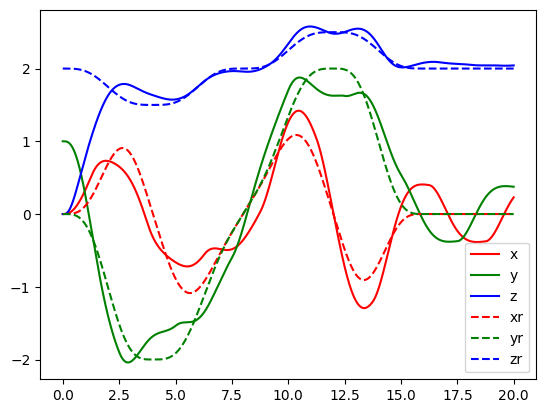

In [20]:
t = np.arange(0, t_list[-1] + dt, dt)
plt.plot(t, np.array(pos_list)[:, 0], "r")
plt.plot(t, np.array(pos_list)[:, 1], "g")
plt.plot(t, np.array(pos_list)[:, 2], "b")

plt.plot(t, np.array(x_list), "r--")
plt.plot(t, np.array(y_list), "g--")
plt.plot(t, np.array(z_list), "b--")
plt.legend(["x", "y", "z", "xr", "yr", "zr"])

# plt.gca().set_xlim(0,15)

# plt.gca().set_ylim(-3,3)

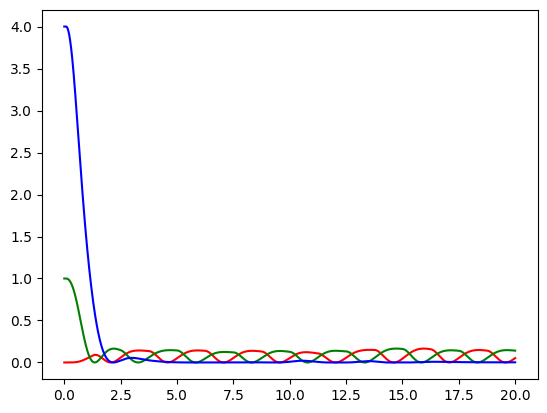

In [21]:
plt.plot(t, (np.array(pos_list)[:, 0] - np.array(x_list))**2, "r")
plt.plot(t, (np.array(pos_list)[:, 1] - np.array(y_list))**2, "g")
plt.plot(t, (np.array(pos_list)[:, 2] - np.array(z_list))**2, "b")

# plt.plot(t, np.array(x_list), "r--")
# plt.plot(t, np.array(y_list), "g--")
# plt.plot(t, np.array(z_list), "b--")
# plt.legend(["x", "y", "z", "xr", "yr", "zr"])